In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [26]:
ALPHABET = [
    "A", "a", "B", "b", "C", "c", "D", "d", "E", "e", "F", "f",
    "G", "g", "H", "h", "I", "i", "J", "j", "K", "k", "L", "l",
    "M", "m", "N", "n", "O", "o", "P", "p", "Q", "q", "R", "r",
    "S", "s", "T", "t", "U", "u", "V", "v", "W", "w", "X", "x",
    "Y", "y", "Z", "z"
]
print(len(ALPHABET))

52


In [27]:
TARGET = "WeLuvNatCompute"
print(len(TARGET))

15


In [28]:
def random_individual(L):
    """Generate a random string of length L from the alphabet."""
    return [ALPHABET[i] for i in np.random.randint(0, len(ALPHABET), size=L)]


def init_population(N, L):
    """Initialize a population of N random strings of length L."""
    return [random_individual(L) for _ in range(N)]


def fitness(individual, target):
    """Fitness = fraction of positions that match the target."""
    return sum(1 for a, b in zip(individual, target) if a == b) / len(target)


def tournament_selection(population, fitnesses, K):
    """Select one individual via tournament selection of size K."""
    indices = np.random.randint(0, len(population), size=K)
    best = indices[0]
    for idx in indices[1:]:
        if fitnesses[idx] > fitnesses[best]:
            best = idx
    return population[best][:]

def crossover(parent1, parent2):
    """Single-point crossover, returns two children."""
    point = np.random.randint(1, len(parent1))  # crossover point in [1, L-1]
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2
    
def mutate(individual, mu):
    """Mutate each position independently with probability mu."""
    ind = individual[:]
    for i in range(len(ind)):
        if np.random.random() < mu:
            ind[i] = ALPHABET[np.random.randint(0, len(ALPHABET))]
    return ind
    
def mean_hamming_distance(population):
    """Compute mean pairwise Hamming distance (sample pairs for speed)."""
    n_pairs = min(500, len(population) * (len(population) - 1) // 2)
    distances = []
    for _ in range(n_pairs):
        i, j = np.random.choice(len(population), size=2, replace=False)
        d = sum(1 for a, b in zip(population[i], population[j]) if a != b)
        distances.append(d)
    return np.mean(distances)


def shannon_entropy(population, L):
    """Compute per-position Shannon entropy averaged over all positions."""
    N = len(population)
    H_total = 0.0
    for i in range(L):
        counts = Counter(ind[i] for ind in population)
        H_i = 0.0
        for c in counts.values():
            f = c / N
            if f > 0:
                H_i -= f * np.log2(f)
        H_total += H_i
    return H_total / L  # mean entropy per position


In [29]:
def genetic_algorithm(K=2, pc=1.0, mu=None, N=200, Gmax=100, target=TARGET,
                       track_diversity_every=10):
    """
    Genetic algorithm for string search 

    Parameters
    ----------
    K : int (Tournament size)
    pc : float (Crossover probability)
    mu : float or None (Mutation rate per character, Defaults to 1/L)
    N : int (Population size)
    Gmax : int (Maximum number of generations)
    target : str 
    track_diversity_every : int

    Returns
    -------
    dict with keys:
        'best_fitness_history'  : list of best fitness per generation
        'mean_fitness_history'  : list of mean fitness per generation
        'diversity_hamming'     : list of (gen, mean_hamming) tuples
        'diversity_entropy'     : list of (gen, mean_entropy) tuples
        't_finish'             : generation at which target was found, or None
        'found'                : bool
    """
    L_t = len(target)
    if mu is None:
        mu = 1.0 / L_t

    # Initialize
    population = init_population(N, L_t)
    best_fitness_history = []
    mean_fitness_history = []
    diversity_hamming = []
    diversity_entropy = []
    t_finish = None

    for gen in range(Gmax):
        fitnesses = [fitness(ind, target) for ind in population]
        best_f = max(fitnesses)
        mean_f = np.mean(fitnesses)
        best_fitness_history.append(best_f)
        mean_fitness_history.append(mean_f)

        if gen % track_diversity_every == 0:
            diversity_hamming.append((gen, mean_hamming_distance(population)))
            diversity_entropy.append((gen, shannon_entropy(population, L_t)))
            
        if best_f == 1.0:
            t_finish = gen
            if gen % track_diversity_every != 0:
                diversity_hamming.append((gen, mean_hamming_distance(population)))
                diversity_entropy.append((gen, shannon_entropy(population, L_t)))
            break

        new_population = []
        for _ in range(N // 2):
            p1 = tournament_selection(population, fitnesses, K)
            p2 = tournament_selection(population, fitnesses, K)

            if np.random.random() <= pc:
                c1, c2 = crossover(p1, p2)
            else:
                c1, c2 = p1[:], p2[:]

            c1 = mutate(c1, mu)
            c2 = mutate(c2, mu)

            new_population.extend([c1, c2])

        population = new_population

    if t_finish is None:
        diversity_hamming.append((Gmax - 1, mean_hamming_distance(population)))
        diversity_entropy.append((Gmax - 1, shannon_entropy(population, L_t)))

    return {
        'best_fitness_history': best_fitness_history,
        'mean_fitness_history': mean_fitness_history,
        'diversity_hamming': diversity_hamming,
        'diversity_entropy': diversity_entropy,
        't_finish': t_finish,
        'found': t_finish is not None
    }

## u=1/L, K=2

In [30]:
n_runs = 10
L = len(TARGET)
results = []


for run in range(n_runs):
    res = genetic_algorithm(K=2, mu=1/L, N=200, Gmax=500)
    results.append(res)
    status = f"gen {res['t_finish']}" if res['found'] else "NOT FOUND"
    print(f"Run {run+1:2d}: {status}")

t_finishes = [r['t_finish'] for r in results if r['found']]
print(f"\nFound in {len(t_finishes)}/{n_runs} runs")
if t_finishes:
    print(f"Mean t_finish: {np.mean(t_finishes):.1f} ± {np.std(t_finishes):.1f}")

Run  1: gen 72
Run  2: gen 57
Run  3: gen 47
Run  4: gen 61
Run  5: gen 86
Run  6: gen 56
Run  7: gen 62
Run  8: gen 47
Run  9: gen 37
Run 10: gen 80

Found in 10/10 runs
Mean t_finish: 60.5 ± 14.5


## U=0, K=2

In [34]:
results = []


for run in range(n_runs):
    res = genetic_algorithm(K=2, mu=0, N=200, Gmax=100)
    results.append(res)
    status = f"gen {res['t_finish']}" if res['found'] else "NOT FOUND"
    print(f"Run {run+1:2d}: {status}")

t_finishes = [r['t_finish'] for r in results if r['found']]
best_fitnesses = [np.max(r["best_fitness_history"]) for r in results]
print(f"\nFound in {len(t_finishes)}/{n_runs} runs")
if t_finishes:
    print(f"Mean t_finish: {np.mean(t_finishes):.1f} ± {np.std(t_finishes):.1f}")
print(f"Mean best fitness over {np.mean(best_fitnesses):.1f}run ±  {np.std(best_fitnesses):.1f}")

Run  1: NOT FOUND
Run  2: NOT FOUND
Run  3: NOT FOUND
Run  4: NOT FOUND
Run  5: NOT FOUND
Run  6: NOT FOUND
Run  7: gen 26
Run  8: NOT FOUND
Run  9: NOT FOUND
Run 10: NOT FOUND

Found in 1/10 runs
Mean t_finish: 26.0 ± 0.0
Mean best fitness over 0.8run ±  0.1


## U=3/L, K=2

In [35]:
results = []


for run in range(n_runs):
    res = genetic_algorithm(K=2, mu=3/L, N=200, Gmax=100)
    results.append(res)
    status = f"gen {res['t_finish']}" if res['found'] else "NOT FOUND"
    print(f"Run {run+1:2d}: {status}")

best_fitnesses = [np.max(r["best_fitness_history"]) for r in results]
t_finishes = [r['t_finish'] for r in results if r['found']]
print(f"\nFound in {len(t_finishes)}/{n_runs} runs")
if t_finishes:
    print(f"Mean t_finish: {np.mean(t_finishes):.1f} ± {np.std(t_finishes):.1f}")
print(f"Mean best fitness over {np.mean(best_fitnesses):.1f}run ±  {np.std(best_fitnesses):.1f}")

Run  1: NOT FOUND
Run  2: NOT FOUND
Run  3: NOT FOUND
Run  4: NOT FOUND
Run  5: NOT FOUND
Run  6: NOT FOUND
Run  7: NOT FOUND
Run  8: NOT FOUND
Run  9: NOT FOUND
Run 10: NOT FOUND

Found in 0/10 runs
Mean best fitness over 0.6run ±  0.1


In [36]:
mu_values = {'mu=0': 0, 'mu=1/L': 1/L, 'mu=3/L': 3/L}
all_results = {}

for label, mu_val in mu_values.items():
    runs = []
    for run in range(n_runs):
        res = genetic_algorithm(K=2, mu=mu_val, N=200, Gmax=100)
        runs.append(res)
    all_results[label] = runs
    found = sum(1 for r in runs if r['found'])
    t_f = [r['t_finish'] for r in runs if r['found']]
    print(f"{label}: found {found}/{n_runs}" +
          (f", mean t_finish={np.mean(t_f):.1f}" if t_f else ""))

mu=0: found 0/10
mu=1/L: found 10/10, mean t_finish=55.6
mu=3/L: found 0/10


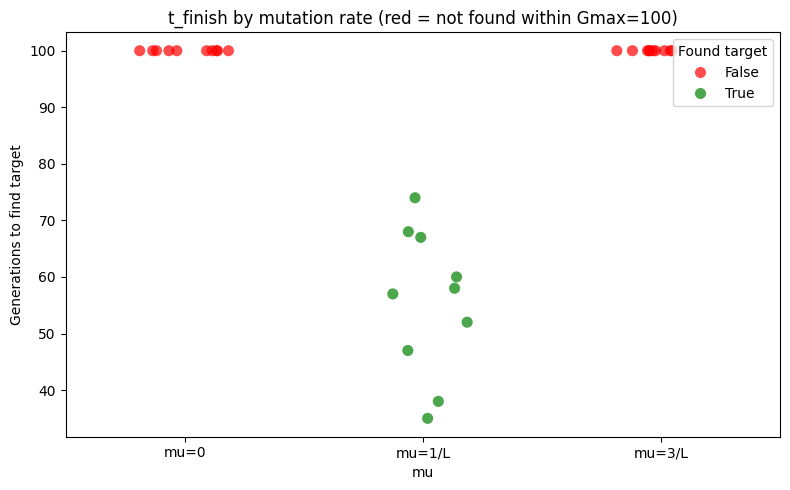

In [38]:
# Beeswarm plot of t_finish across mutation rates
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = []
for label, runs in all_results.items():
    for r in runs:
        t = r['t_finish'] if r['found'] else 100  # cap at Gmax if not found
        plot_data.append({'mu': label, 't_finish': t, 'found': r['found']})

import pandas as pd
df_plot = pd.DataFrame(plot_data)

sns.stripplot(data=df_plot, x='mu', y='t_finish', hue='found',
              jitter=0.2, size=8, alpha=0.7, ax=ax, palette={True: 'green', False: 'red'})
ax.set_ylabel('Generations to find target')
ax.set_title('t_finish by mutation rate (red = not found within Gmax=100)')
ax.legend(title='Found target')
plt.tight_layout()
plt.show()

## diversity analysis

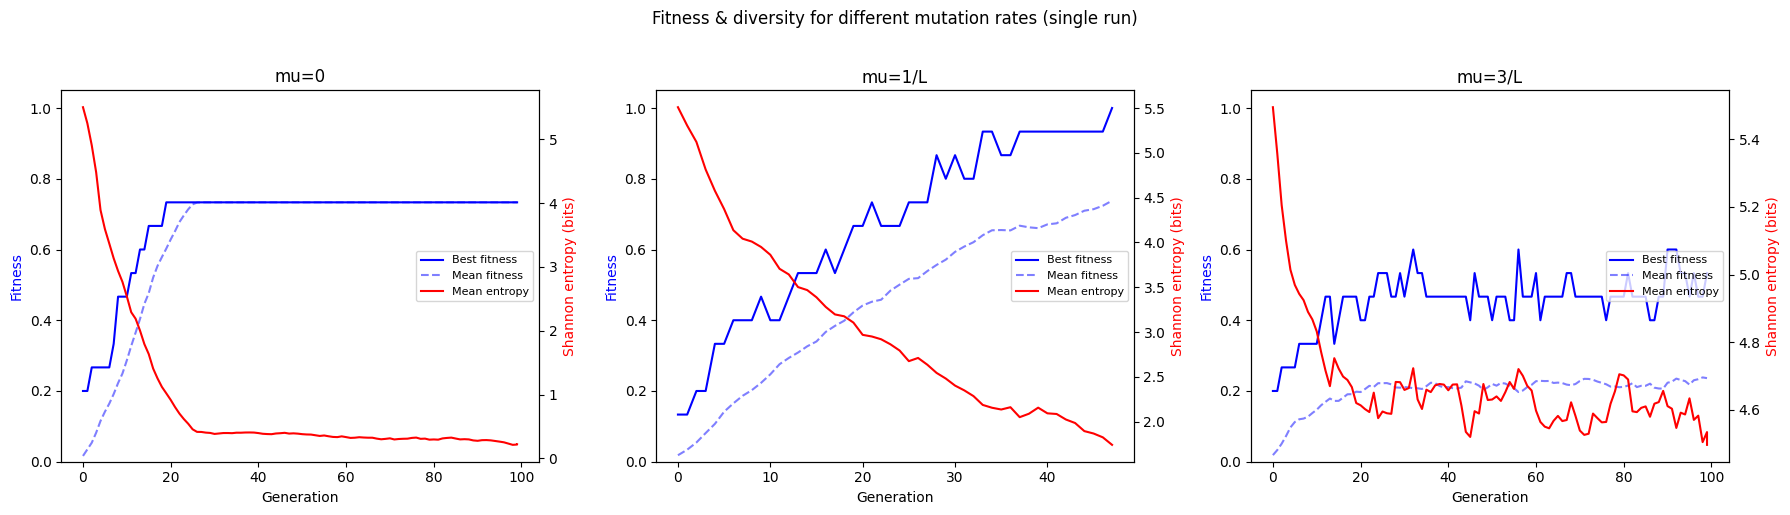

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, mu_val) in enumerate(mu_values.items()):
    res = genetic_algorithm(K=2, mu=mu_val, N=200, Gmax=100, track_diversity_every=1)

    gens_fit = range(len(res['best_fitness_history']))
    gens_div = [x[0] for x in res['diversity_entropy']]
    entropy_vals = [x[1] for x in res['diversity_entropy']]

    ax = axes[idx]
    ax2 = ax.twinx()

    ax.plot(gens_fit, res['best_fitness_history'], 'b-', label='Best fitness')
    ax.plot(gens_fit, res['mean_fitness_history'], 'b--', alpha=0.5, label='Mean fitness')
    ax2.plot(gens_div, entropy_vals, 'r-', label='Mean entropy')

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness', color='b')
    ax2.set_ylabel('Shannon entropy (bits)', color='r')
    ax.set_title(f'{label}')
    ax.set_ylim(0, 1.05)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

plt.suptitle('Fitness & diversity for different mutation rates (single run)', y=1.02)
plt.tight_layout()
plt.show()

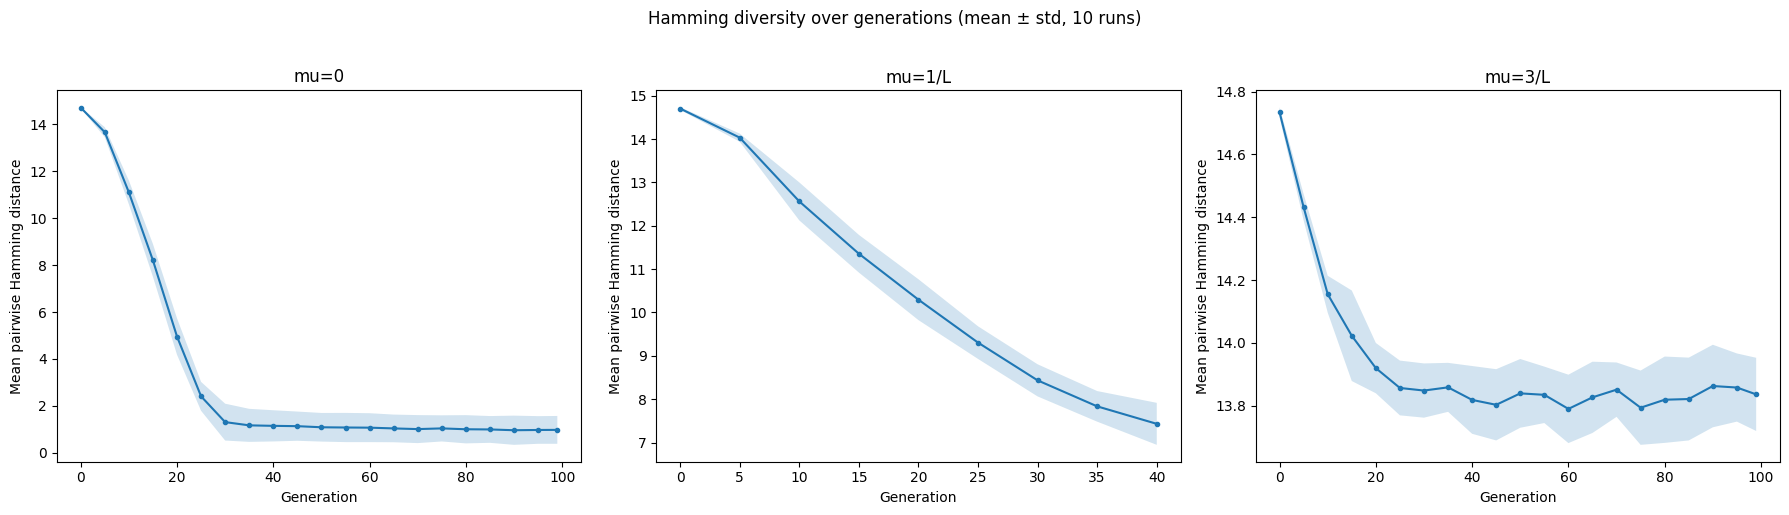

In [40]:
# Hamming distance diversity over 10 runs (averaged)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, mu_val) in enumerate(mu_values.items()):
    all_hamming = []
    for _ in range(n_runs):
        res = genetic_algorithm(K=2, mu=mu_val, N=200, Gmax=100, track_diversity_every=5)
        hamming_dict = dict(res['diversity_hamming'])
        all_hamming.append(hamming_dict)

    # Collect common generations
    common_gens = sorted(set.intersection(*[set(h.keys()) for h in all_hamming]))
    mean_h = [np.mean([h[g] for h in all_hamming]) for g in common_gens]
    std_h = [np.std([h[g] for h in all_hamming]) for g in common_gens]

    ax = axes[idx]
    ax.plot(common_gens, mean_h, 'o-', markersize=3)
    ax.fill_between(common_gens,
                    np.array(mean_h) - np.array(std_h),
                    np.array(mean_h) + np.array(std_h), alpha=0.2)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Mean pairwise Hamming distance')
    ax.set_title(f'{label}')

plt.suptitle('Hamming diversity over generations (mean ± std, 10 runs)', y=1.02)
plt.tight_layout()
plt.show()

In [45]:
mu_sweep = np.array([0, 0.5/L, 1/L, 1.5/L, 2/L, 2.5/L, 3/L, 4/L, 5/L, 7/L, 10/L])
sweep_results_K2 = {}

for mu_val in mu_sweep:
    runs = []
    for _ in range(n_runs):
        res = genetic_algorithm(K=2, mu=mu_val, N=200, Gmax=200)
        runs.append(res)
    sweep_results_K2[mu_val] = runs
    found = sum(1 for r in runs if r['found'])
    mean_t = np.mean([r['t_finish'] for r in runs if r['found']]) if found > 0 else float('nan')
    print(f"mu={mu_val:.4f} ({mu_val*L:.1f}/L): found {found}/{n_runs}, mean t_finish={mean_t:.1f}")

mu=0.0000 (0.0/L): found 1/10, mean t_finish=25.0
mu=0.0333 (0.5/L): found 10/10, mean t_finish=48.8
mu=0.0667 (1.0/L): found 10/10, mean t_finish=68.1
mu=0.1000 (1.5/L): found 5/10, mean t_finish=126.6
mu=0.1333 (2.0/L): found 0/10, mean t_finish=nan
mu=0.1667 (2.5/L): found 0/10, mean t_finish=nan
mu=0.2000 (3.0/L): found 0/10, mean t_finish=nan
mu=0.2667 (4.0/L): found 0/10, mean t_finish=nan
mu=0.3333 (5.0/L): found 0/10, mean t_finish=nan
mu=0.4667 (7.0/L): found 0/10, mean t_finish=nan
mu=0.6667 (10.0/L): found 0/10, mean t_finish=nan


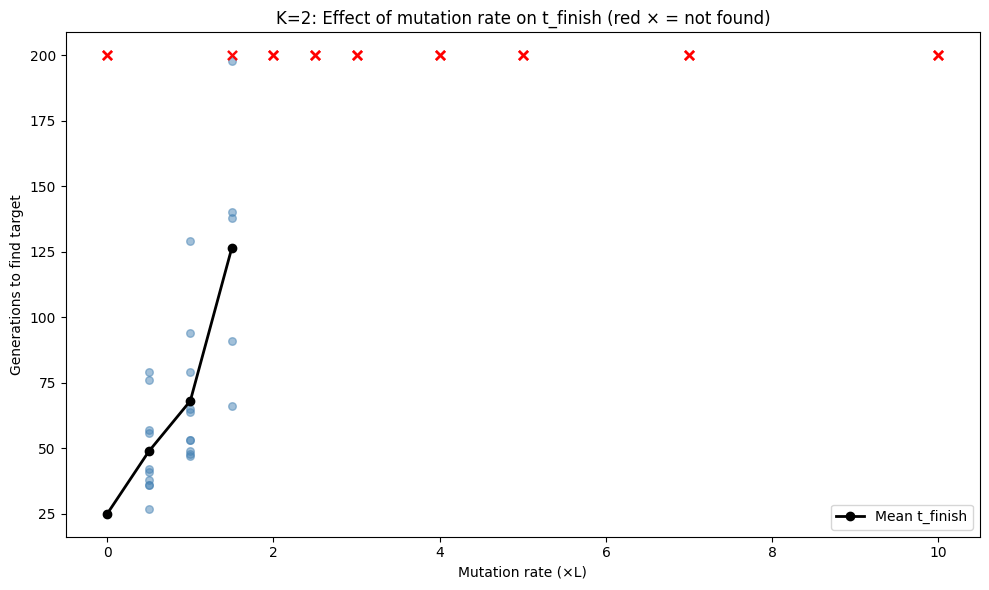

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

mu_labels = []
for mu_val in mu_sweep:
    runs = sweep_results_K2[mu_val]
    for r in runs:
        t = r['t_finish'] if r['found'] else 200
        color = 'steelblue' if r['found'] else 'red'
        marker = 'o' if r['found'] else 'x'
        ax.scatter(mu_val * L, t, color=color, alpha=0.5, s=30 if r['found'] else 40, marker=marker)

# Plot mean line
means = []
mus_plot = []
for mu_val in mu_sweep:
    t_found = [r['t_finish'] for r in sweep_results_K2[mu_val] if r['found']]
    if t_found:
        means.append(np.mean(t_found))
        mus_plot.append(mu_val * L)

ax.plot(mus_plot, means, 'k-o', linewidth=2, markersize=6, label='Mean t_finish')

ax.set_xlabel('Mutation rate (×L)')
ax.set_ylabel('Generations to find target')
ax.set_title('K=2: Effect of mutation rate on t_finish (red × = not found)')
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
sweep_results_K5 = {}

for mu_val in mu_sweep:
    runs = []
    for _ in range(n_runs):
        res = genetic_algorithm(K=5, mu=mu_val, N=200, Gmax=200)
        runs.append(res)
    sweep_results_K5[mu_val] = runs
    found = sum(1 for r in runs if r['found'])
    mean_t = np.mean([r['t_finish'] for r in runs if r['found']]) if found > 0 else float('nan')
    print(f"µ={mu_val:.4f} ({mu_val*L:.1f}/L): found {found}/{n_runs}, mean t_finish={mean_t:.1f}")

µ=0.0000 (0.0/L): found 0/10, mean t_finish=nan
µ=0.0333 (0.5/L): found 10/10, mean t_finish=26.4
µ=0.0667 (1.0/L): found 10/10, mean t_finish=23.7
µ=0.1000 (1.5/L): found 10/10, mean t_finish=26.5
µ=0.1333 (2.0/L): found 10/10, mean t_finish=29.5
µ=0.1667 (2.5/L): found 10/10, mean t_finish=62.7
µ=0.2000 (3.0/L): found 0/10, mean t_finish=nan
µ=0.2667 (4.0/L): found 0/10, mean t_finish=nan
µ=0.3333 (5.0/L): found 0/10, mean t_finish=nan
µ=0.4667 (7.0/L): found 0/10, mean t_finish=nan
µ=0.6667 (10.0/L): found 0/10, mean t_finish=nan


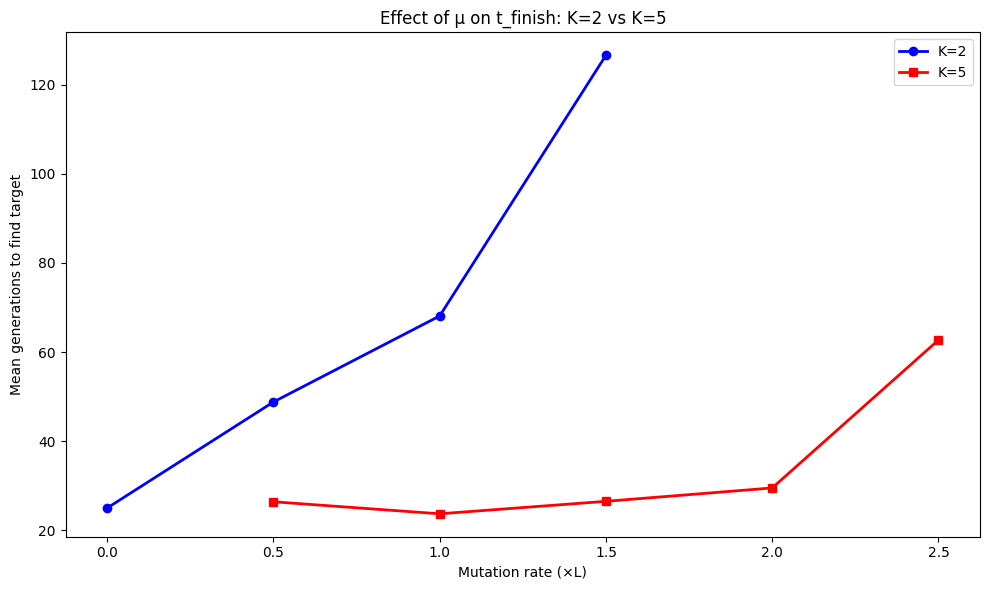

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

# K=2
means_K2, mus_K2 = [], []
for mu_val in mu_sweep:
    t_found = [r['t_finish'] for r in sweep_results_K2[mu_val] if r['found']]
    if t_found:
        means_K2.append(np.mean(t_found))
        mus_K2.append(mu_val * L)
ax.plot(mus_K2, means_K2, 'b-o', linewidth=2, label='K=2')

# K=5
means_K5, mus_K5 = [], []
for mu_val in mu_sweep:
    t_found = [r['t_finish'] for r in sweep_results_K5[mu_val] if r['found']]
    if t_found:
        means_K5.append(np.mean(t_found))
        mus_K5.append(mu_val * L)
ax.plot(mus_K5, means_K5, 'r-s', linewidth=2, label='K=5')

ax.set_xlabel('Mutation rate (×L)')
ax.set_ylabel('Mean generations to find target')
ax.set_title('Effect of µ on t_finish: K=2 vs K=5')
ax.legend()
plt.tight_layout()
plt.show()

## Sweep comparison: Best fitness, Mean fitness & Diversity

In [49]:
def sweep_summary(sweep_results, mu_sweep, L):
    """Extract per-mu summary statistics from sweep results."""
    mu_labels = []
    mean_best_fit, std_best_fit = [], []
    mean_mean_fit, std_mean_fit = [], []
    mean_final_entropy, std_final_entropy = [], []
    mean_final_hamming, std_final_hamming = [], []
    convergence_rate = []

    for mu_val in mu_sweep:
        runs = sweep_results[mu_val]
        mu_labels.append(f"{mu_val*L:.1f}/L")

        # Best fitness achieved per run (max over all generations)
        best_fits = [max(r['best_fitness_history']) for r in runs]
        mean_best_fit.append(np.mean(best_fits))
        std_best_fit.append(np.std(best_fits))

        # Mean fitness at final generation per run
        final_mean_fits = [r['mean_fitness_history'][-1] for r in runs]
        mean_mean_fit.append(np.mean(final_mean_fits))
        std_mean_fit.append(np.std(final_mean_fits))

        # Final entropy per run
        final_entropies = [r['diversity_entropy'][-1][1] for r in runs]
        mean_final_entropy.append(np.mean(final_entropies))
        std_final_entropy.append(np.std(final_entropies))

        # Final hamming per run
        final_hammings = [r['diversity_hamming'][-1][1] for r in runs]
        mean_final_hamming.append(np.mean(final_hammings))
        std_final_hamming.append(np.std(final_hammings))

        # Convergence rate
        convergence_rate.append(sum(1 for r in runs if r['found']) / len(runs))

    return {
        'mu_labels': mu_labels,
        'mu_numeric': mu_sweep * L,
        'mean_best_fit': np.array(mean_best_fit),
        'std_best_fit': np.array(std_best_fit),
        'mean_mean_fit': np.array(mean_mean_fit),
        'std_mean_fit': np.array(std_mean_fit),
        'mean_final_entropy': np.array(mean_final_entropy),
        'std_final_entropy': np.array(std_final_entropy),
        'mean_final_hamming': np.array(mean_final_hamming),
        'std_final_hamming': np.array(std_final_hamming),
        'convergence_rate': np.array(convergence_rate),
    }

summary_K2 = sweep_summary(sweep_results_K2, mu_sweep, L)
summary_K5 = sweep_summary(sweep_results_K5, mu_sweep, L)

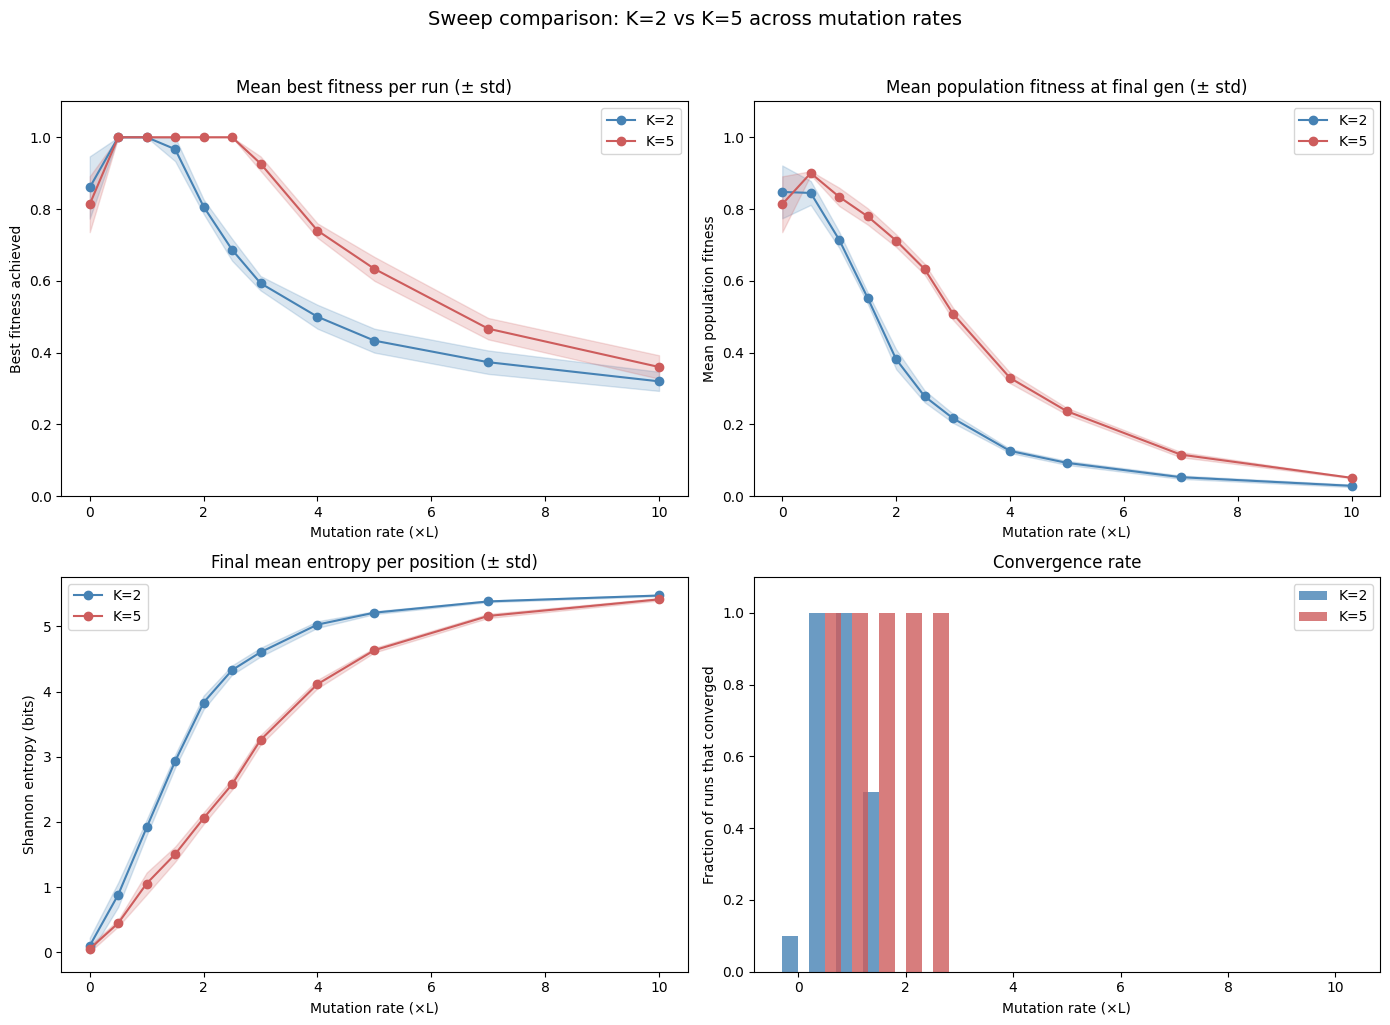

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = summary_K2['mu_numeric']

# --- Mean Best Fitness ---
ax = axes[0, 0]
for summary, label, color in [(summary_K2, 'K=2', 'steelblue'), (summary_K5, 'K=5', 'indianred')]:
    ax.plot(x, summary['mean_best_fit'], 'o-', color=color, label=label)
    ax.fill_between(x, summary['mean_best_fit'] - summary['std_best_fit'],
                       summary['mean_best_fit'] + summary['std_best_fit'], alpha=0.2, color=color)
ax.set_ylabel('Best fitness achieved')
ax.set_title('Mean best fitness per run (± std)')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_xlabel('Mutation rate (×L)')

# --- Mean Mean Fitness (final generation) ---
ax = axes[0, 1]
for summary, label, color in [(summary_K2, 'K=2', 'steelblue'), (summary_K5, 'K=5', 'indianred')]:
    ax.plot(x, summary['mean_mean_fit'], 'o-', color=color, label=label)
    ax.fill_between(x, summary['mean_mean_fit'] - summary['std_mean_fit'],
                       summary['mean_mean_fit'] + summary['std_mean_fit'], alpha=0.2, color=color)
ax.set_ylabel('Mean population fitness')
ax.set_title('Mean population fitness at final gen (± std)')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_xlabel('Mutation rate (×L)')

# --- Final Shannon Entropy ---
ax = axes[1, 0]
for summary, label, color in [(summary_K2, 'K=2', 'steelblue'), (summary_K5, 'K=5', 'indianred')]:
    ax.plot(x, summary['mean_final_entropy'], 'o-', color=color, label=label)
    ax.fill_between(x, summary['mean_final_entropy'] - summary['std_final_entropy'],
                       summary['mean_final_entropy'] + summary['std_final_entropy'], alpha=0.2, color=color)
ax.set_ylabel('Shannon entropy (bits)')
ax.set_title('Final mean entropy per position (± std)')
ax.legend()
ax.set_xlabel('Mutation rate (×L)')

# --- Convergence Rate ---
ax = axes[1, 1]
ax.bar(x - 0.15, summary_K2['convergence_rate'], width=0.3, label='K=2', color='steelblue', alpha=0.8)
ax.bar(x + 0.15, summary_K5['convergence_rate'], width=0.3, label='K=5', color='indianred', alpha=0.8)
ax.set_ylabel('Fraction of runs that converged')
ax.set_title('Convergence rate')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_xlabel('Mutation rate (×L)')

plt.suptitle('Sweep comparison: K=2 vs K=5 across mutation rates', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()